# **MÓDULO 39 - Exercicio - Aplicando XGboost**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros.
Já utilizamos essa base antes, nessa atividade, você deve carregar a base, realizar os tratamentos necessários, rodar o XGBoost, encontrar as principais variaveis.
Vamos lá!

In [22]:
# BIBLIOTECAS UTILIZADAS

import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.discriminant_analysis import StandardScaler

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [23]:
# IMPORTAÇÃO DE DADOS

df = pd.read_csv("CARRO_CLIENTES.csv")

In [24]:
# VERIFICANDO TIPOS DE DADOS

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [25]:
# ESPECIFICANDO TIPO DE VARIÁVEL 

df["Gender"] = df["Gender"].astype("string")

In [26]:
# VERIFICANDO DADOS NULOS

df.isnull().mean() * 100

User ID         0.0
Gender          0.0
Age             0.0
AnnualSalary    0.0
Purchased       0.0
dtype: float64

In [27]:
# PADRONIZAÇÃO DE NOME DAS COLUNAS

df.columns = df.columns.str.upper()
df.columns = df.columns.str.replace(" ", "_")
df = df.rename(columns={"ANNUALSALARY": "ANNUAL_SALARY"})
df['GENDER'] = df['GENDER'].str.upper() 

In [28]:
# VERIFICAÇÃO DE ERROS DE DIGITAÇÃO 

df['GENDER'].value_counts()

GENDER
FEMALE    516
MALE      484
Name: count, dtype: Int64

In [29]:
# PRÉVIA

df.head()

,USER_ID,GENDER,AGE,ANNUAL_SALARY,PURCHASED
0,385,MALE,35,20000,0
1,681,MALE,40,43500,0
2,353,MALE,49,74000,0
3,895,MALE,40,107500,1
4,661,MALE,25,79000,0


In [30]:
# VERIFICANDO ERROS DE DIGITAÇÃO E POSSÍVEL PRESENÇA DE OUTLIERS NA COLUNA AGE

print(df['AGE'].describe().round(2))

fig = px.box(df, y="AGE")
fig.show()

count    1000.00
mean       40.11
std        10.71
min        18.00
25%        32.00
50%        40.00
75%        48.00
max        63.00
Name: AGE, dtype: float64


In [31]:
# VERIFICANDO ERROS DE DIGITAÇÃO E POSSÍVEL PRESENÇA DE OUTLIERS NA COLUNA ANNUAL_SALARY

print(df['ANNUAL_SALARY'].describe().round(2))

fig = px.box(df, y="ANNUAL_SALARY")
fig.show()

count      1000.00
mean      72689.00
std       34488.34
min       15000.00
25%       46375.00
50%       72000.00
75%       90000.00
max      152500.00
Name: ANNUAL_SALARY, dtype: float64


In [32]:
# ELIMINANDO COLUNA DESNECESSÁRIA

df = df.drop(columns='USER_ID')

# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

**OBSERVAÇÃO:** O Label Encoder não seria a opção mais adequada para a variável GENDER, por se tratar de uma feature categórica nominal. Portanto, optei por utilizar o One-Hot Encoder. Vale destacar que o Label Encoding introduz ordem artificial, o que poderia prejudicar a previsão do modelo.

In [33]:
# ONE-HOT ENCODER

df = pd.get_dummies(df, columns=['GENDER'], drop_first=True)
df['GENDER_MALE'] = df['GENDER_MALE'].astype(int)

# 3. Faça a matriz de correlação e analise as variáveis que parecem ter maior correlação com a váriavel target.

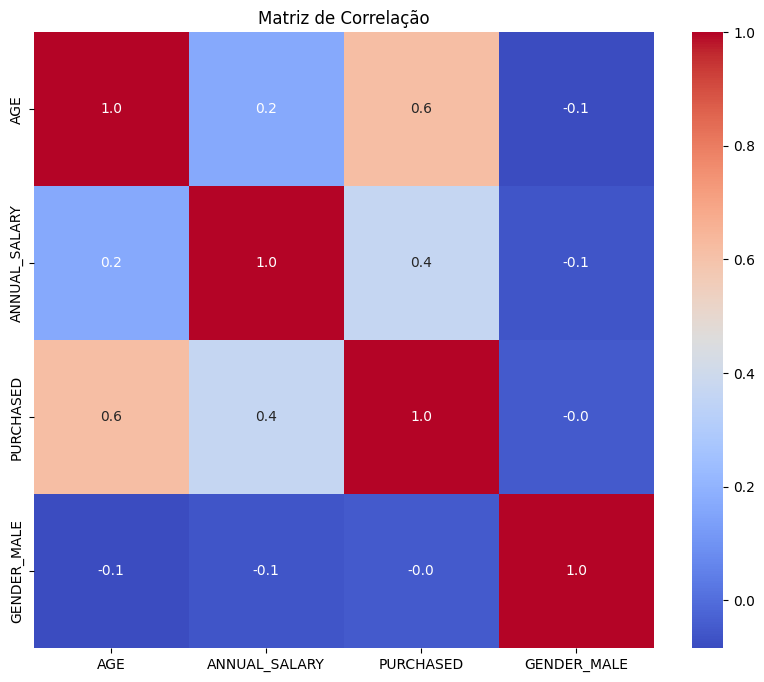

In [34]:
# MATRIZ DE CORRELAÇÃO

correlation_matrix = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".1f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

**ANÁLISE:** Temos que as variáveis que mais relevantes para o treinamento do modelo são: `AGE` e `ANNUAL_SALARY`

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [35]:
# SEPARAÇÃO DE BASE TESTE E TRENO

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('PURCHASED', axis=1),
    df['PURCHASED'],
    test_size=0.25,
    random_state=0
)

In [36]:
# PADRONIZAÇÃO DE DADOS

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Treino o modelo Xgboost com sua base de treino.
Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

In [37]:
# APLICAÇÃO DO MODELO COM HYPERPARAMETROS

model_xgboost_hyper = xgb.XGBClassifier(
    booster = 'dart',
    n_estimators=1000,

)

model_xgboost = xgb.XGBClassifier().fit(X_train, y_train)
model_xgboost.objective

'binary:logistic'

# 6. Realize as previsões para a base de teste e traga as probabilidades das previsões.

In [38]:
# PREVISÕES PARA A BASE TESTE

y_pred = model_xgboost.predict(X_test)        
y_pred_prob = model_xgboost.predict_proba(X_test) 

In [39]:
# TABELA DE PROBABILIDADE

print("TABELA DE PROBABILIDADE")

probs_df = pd.DataFrame(
    y_pred_prob,
    columns=["CLASSE_0", "CLASSE_1"]
).round(2)

probs_df

TABELA DE PROBABILIDADE


,CLASSE_0,CLASSE_1
0,0.01,0.99
1,1.00,0.00
2,0.00,1.00
3,1.00,0.00
4,1.00,0.00
...,...,...
245,1.00,0.00
246,1.00,0.00
247,0.18,0.82
248,0.03,0.97


# 7. Faça a transformação das probabilidades nas previsões binárias e avalie o desempenho do modelo.

In [40]:
# RELATÓRIO DE CLASSIFICAÇÃO

report = classification_report(y_test, y_pred)

print('RELATÓRIO DE CLASSIFICAÇÃO:')
print(report)

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       152
           1       0.90      0.83      0.86        98

    accuracy                           0.90       250
   macro avg       0.90      0.88      0.89       250
weighted avg       0.90      0.90      0.90       250



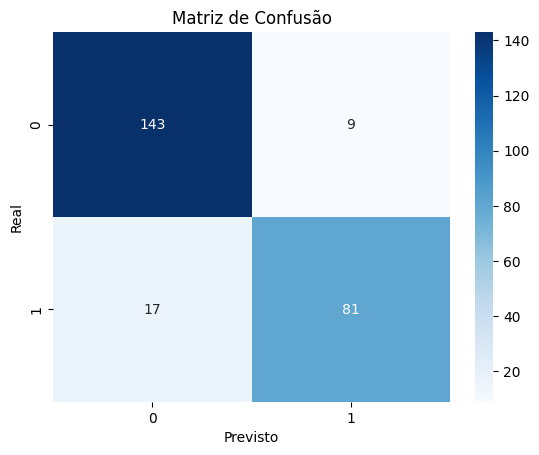

In [41]:
# APRESENTAÇÃO DE MATRIZ DE CONFUSÃO

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

**ANÁLISE:** Podemos concluir a partir do relatório de classificação e apresentação da matriz de confusão que o modelo atingiu excelentes resultados em todas as métrias (todas acima de 90%). Vale destacar também que o modelo recebeu mais amostras da classe 0 em relação à classe 1, o que trouxe como consequência resultados ligeiramente mais precisos para essa classe.

# 8. Traga a lista com a feature importance.
As features mais importantes são as mesmas que indicaram maior correlação na matriz de correlação?

In [42]:
importances = model_xgboost.get_booster().get_score(importance_type='gain')

importance_df = pd.DataFrame(list(importances.items()), columns=['Feature', 'Importance'])
importance_df['Importance'] = importance_df['Importance'].astype(float)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

         Feature  Importance
0            AGE    1.658819
1  ANNUAL_SALARY    1.058641
2    GENDER_MALE    0.415522
